### Task 3

In [23]:
import pandas as pd
from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer

In [24]:
train_df = pd.read_csv("train.csv")
store_df = pd.read_csv("store.csv")
df = pd.merge(train_df, store_df, on = "Store")
df.head()

C:\Users\bartik\AppData\Local\Temp\ipykernel_17680\4029206286.py:1: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv("train.csv")


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [25]:
text_cols = df.select_dtypes(exclude=['number']).columns
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_columns = ["Store", "StoreType", "Assortment", "DayOfWeek", "Open", "Promo", "StateHoliday", "SchoolHoliday"]

In [26]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(by=["Store", "Date"])
df["time_idx"] = (df["Date"] - df["Date"].min()).dt.days

df[numeric_cols] = df[numeric_cols].fillna(0)
df[text_cols] = df[text_cols].fillna("0")
for col in categorical_columns:
    df[col] = df[col].astype(str)

df["Sales"] = df["Sales"].astype(float)
df["Customers"] = df["Customers"].astype(float)

df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,time_idx
1016095,1,2,2013-01-01,0.0,0.0,0,0,a,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,0
1014980,1,3,2013-01-02,5530.0,668.0,1,0,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,1
1013865,1,4,2013-01-03,4327.0,578.0,1,0,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2
1012750,1,5,2013-01-04,4486.0,619.0,1,0,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,3
1011635,1,6,2013-01-05,4997.0,635.0,1,0,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,4


In [27]:
selected_stores = df['Store'].unique()[:10]

df_mini = df[df['Store'].isin(selected_stores)].copy()
df_mini = df_mini.sort_values(by=['Store', 'Date'])

In [28]:
MAX_ENC = 30
MAX_PRED = 7
cutoff = df_mini["time_idx"].max() - 30

In [29]:
training = TimeSeriesDataSet(df_mini[df_mini.time_idx <= cutoff], time_idx = "time_idx", target = "Sales", group_ids = ["Store"],
                             max_encoder_length= MAX_ENC, max_prediction_length= MAX_PRED,
                             static_categoricals=["Store", "StoreType", "Assortment"],
                             time_varying_known_categoricals=["DayOfWeek", "Promo", "StateHoliday", "SchoolHoliday", "Open"],
                             time_varying_unknown_reals= ["Sales", "Customers"],
                             target_normalizer=GroupNormalizer(groups=["Store"], transformation = "softplus"),
                             allow_missing_timesteps=True, 
                             add_relative_time_idx=True,
                             add_target_scales=True,
                             add_encoder_length=True,)

In [30]:
validation = TimeSeriesDataSet.from_dataset(
    training, 
    df_mini, 
    predict=True, 
    stop_randomization=True
)

batch_size = 64
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size * 2, num_workers=0)

In [31]:
import lightning.pytorch as pl
from pytorch_forecasting import TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.001,
    hidden_size=16,
    attention_head_size=4,
    dropout=0.2,
    hidden_continuous_size=8,
    loss=QuantileLoss(),
)

trainer = pl.Trainer(
    max_epochs=5,
    accelerator="cpu",        
    gradient_clip_val=0.1,
    enable_progress_bar = True        
)

trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader
)

c:\Users\bartik\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\bartik\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://py

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    117 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │     96 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  2.1 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  2.5 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  1.1 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    676 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    119 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 19.7 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 19.7 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 325                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\bartik\AppData\Local\Programs\Python\Python312\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\bartik\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21
: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

c:\Users\bartik\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\trainer\connectors\data
_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

c:\Users\bartik\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\trainer\connectors\data
_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=5` reached.


In [ ]:
import matplotlib.pyplot as plt

raw_preds = tft.predict(val_dataloader, mode="raw", return_x=True)

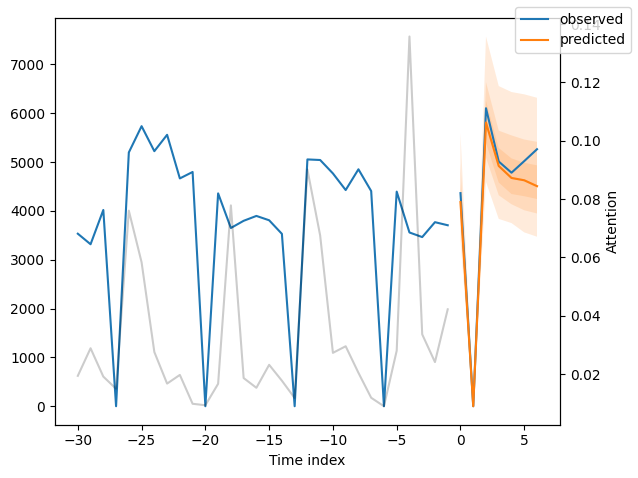

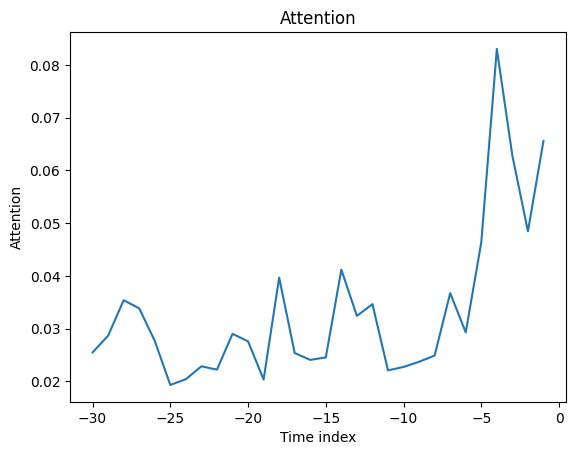

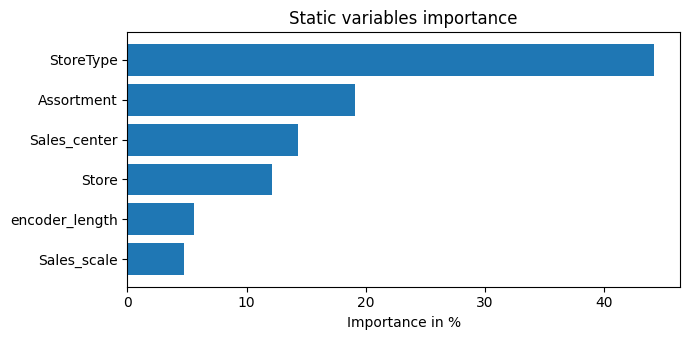

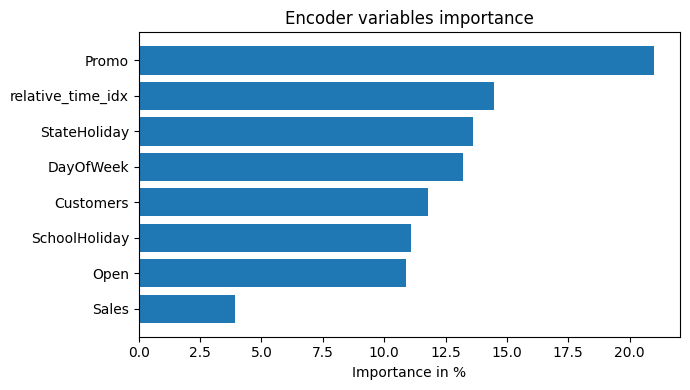

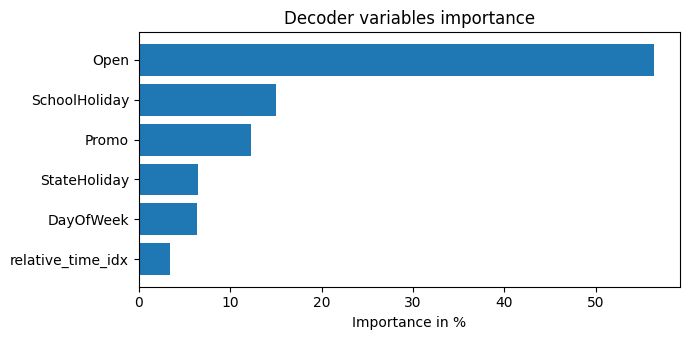

In [44]:
tft.plot_prediction(raw_preds.x, raw_preds.output, idx=0)
plt.tight_layout()
plt.show()

interpretation = tft.interpret_output(raw_preds.output, reduction="sum")
tft.plot_interpretation(interpretation)
plt.tight_layout()
plt.show()

### Task 4

In [33]:
selected_stores = df['Store'].unique()[:10]

df_mini = df[df['Store'].isin(selected_stores)].copy()
df_mini = df_mini.sort_values(by=['Store', 'Date'])

In [34]:
import time
import tracemalloc
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [35]:
import warnings
import pmdarima as pm
import numpy as np

warnings.filterwarnings("ignore")


tracemalloc.start()
start_time = time.time()

arima_rmse = []
arima_mae = []
arima_mape = []

for store_id in selected_stores:
    print(f"Training ARIMA for Store {store_id}...")
    store_data = df_mini[df_mini['Store'] == store_id][['Date', 'Sales']].set_index('Date')
    
    train_size = len(store_data) - 30
    train_data = store_data.iloc[:train_size]
    test_data = store_data.iloc[train_size:]
    
    model = pm.auto_arima(
        train_data['Sales'], 
        seasonal=True, 
        stepwise = True,
        m=7, 
        suppress_warnings=True,
        error_action="ignore"
    )
    
    preds = model.predict(n_periods=len(test_data))
    
    rmse = np.sqrt(mean_squared_error(test_data['Sales'].values, preds.values))
    mae = mean_absolute_error(test_data['Sales'].values, preds.values)
    mask = test_data['Sales'].values != 0
    mape = np.mean(np.abs((test_data['Sales'].values[mask] - preds.values[mask]) / test_data['Sales'].values[mask])) * 100
    
    arima_rmse.append(rmse)
    arima_mae.append(mae)
    arima_mape.append(mape)

end_time = time.time()
current_mem, peak_mem = tracemalloc.get_traced_memory()
arima_time = end_time - start_time
arima_mem = peak_mem / 10**6
tracemalloc.stop()

print(f"Total training time: {end_time - start_time:.2f} seconds")
print(f"Peak memory usage: {peak_mem / 10**6:.2f} MB")

print("\n--- AVERAGE ARIMA RESULTS (10 STORES) ---")
print(f"Average RMSE: {np.mean(arima_rmse):.2f}")
print(f"Average MAE:  {np.mean(arima_mae):.2f}")
print(f"Average MAPE: {np.nanmean(arima_mape):.2f}%")

Training ARIMA for Store 1...
Training ARIMA for Store 2...
Training ARIMA for Store 3...
Training ARIMA for Store 4...
Training ARIMA for Store 5...
Training ARIMA for Store 6...
Training ARIMA for Store 7...
Training ARIMA for Store 8...
Training ARIMA for Store 9...
Training ARIMA for Store 10...
Total training time: 807.08 seconds
Peak memory usage: 1222.46 MB

--- AVERAGE ARIMA RESULTS (10 STORES) ---
Average RMSE: 3140.42
Average MAE:  2581.05
Average MAPE: 41.32%


In [36]:
import warnings
from prophet import Prophet
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")

prophet_rmse = []
prophet_mae = []
prophet_mape = []

tracemalloc.start()
start_time = time.time()

for store_id in selected_stores:
    print(f"Training Prophet for Store {store_id}...")
    
    store_data = df_mini[df_mini['Store'] == store_id][['Date', 'Sales']].copy()
    store_data.rename(columns={'Date': 'ds', 'Sales': 'y'}, inplace=True)
    
    train_size = len(store_data) - 30
    train_data = store_data.iloc[:train_size]
    test_data = store_data.iloc[train_size:]
    
    model = Prophet(yearly_seasonality=True, daily_seasonality=False)
    model.fit(train_data)
    
    future = model.make_future_dataframe(periods=len(test_data))
    forecast = model.predict(future)
    
    preds = forecast['yhat'][-len(test_data):].values
    actuals = test_data['y'].values
    
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae = mean_absolute_error(actuals, preds)
    mask = actuals != 0
    
    if np.any(mask):
        mape = np.mean(np.abs((actuals[mask] - preds[mask]) / actuals[mask])) * 100
    else:
        mape = np.nan
        
    prophet_rmse.append(rmse)
    prophet_mae.append(mae)
    prophet_mape.append(mape)

end_time = time.time()
current_mem, peak_mem = tracemalloc.get_traced_memory()
prophet_time = end_time - start_time
prophet_mem = peak_mem/10**6
tracemalloc.stop()
print(f"Total training time: {end_time - start_time:.2f} seconds")
print(f"Peak memory usage: {peak_mem / 10**6:.2f} MB")

print("\n--- AVERAGE PROPHET RESULTS (10 STORES) ---")
print(f"Average RMSE: {np.mean(prophet_rmse):.2f}")
print(f"Average MAE:  {np.mean(prophet_mae):.2f}")
print(f"Average MAPE: {np.nanmean(prophet_mape):.2f}%")

Importing plotly failed. Interactive plots will not work.


Training Prophet for Store 1...


00:56:00 - cmdstanpy - INFO - Chain [1] start processing
00:56:01 - cmdstanpy - INFO - Chain [1] done processing


Training Prophet for Store 2...


00:56:02 - cmdstanpy - INFO - Chain [1] start processing
00:56:02 - cmdstanpy - INFO - Chain [1] done processing


...

Training Prophet for Store 9...


00:56:09 - cmdstanpy - INFO - Chain [1] start processing
00:56:09 - cmdstanpy - INFO - Chain [1] done processing


Training Prophet for Store 10...


00:56:10 - cmdstanpy - INFO - Chain [1] start processing
00:56:10 - cmdstanpy - INFO - Chain [1] done processing


Total training time: 13.18 seconds
Peak memory usage: 40.75 MB

--- AVERAGE PROPHET RESULTS (10 STORES) ---
Average RMSE: 1133.28
Average MAE:  933.23
Average MAPE: 15.88%


In [37]:
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1, output_size=30):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.linear(out[:, -1, :])
        return out

def create_sequences(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data) - seq_length - 30):
        x = data[i:(i + seq_length)]
        y = data[(i + seq_length):(i + seq_length + 30)]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

lstm_rmse = []
lstm_mae = []
lstm_mape = []

seq_length = 60
epochs = 50

tracemalloc.start()
start_time = time.time()

for store_id in selected_stores:
    print(f"Training LSTM for Store {store_id}...")
    store_data = df_mini[df_mini['Store'] == store_id][['Sales']].values
    
    scaler = MinMaxScaler(feature_range=(-1, 1))
    scaled_data = scaler.fit_transform(store_data)
    
    X, y = create_sequences(scaled_data, seq_length)
    
    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32).squeeze()
    
    train_size = int(len(X) * 0.9)
    X_train, y_train = X[:train_size], y[:train_size]
    
    model = LSTMModel()
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(X_train)
        loss = criterion(out, y_train)
        loss.backward()
        optimizer.step()
        
    model.eval()
    with torch.no_grad():
        last_sequence = scaled_data[-seq_length-30:-30]
        last_sequence = torch.tensor(last_sequence, dtype=torch.float32).unsqueeze(0)
        
        preds_scaled = model(last_sequence).numpy().reshape(-1, 1)
        preds = scaler.inverse_transform(preds_scaled).flatten()
        
    actuals = store_data[-30:].flatten()
    
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae = mean_absolute_error(actuals, preds)
    mask = actuals != 0
    mape = np.mean(np.abs((actuals[mask] - preds[mask]) / actuals[mask])) * 100
    
    lstm_rmse.append(rmse)
    lstm_mae.append(mae)
    lstm_mape.append(mape)

end_time = time.time()
current_mem, peak_mem = tracemalloc.get_traced_memory()
lstm_time = end_time - start_time
lstm_mem = peak_mem/10**6
tracemalloc.stop()

print(f"Total training time: {end_time - start_time:.2f} seconds")
print(f"Peak memory usage: {peak_mem / 10**6:.2f} MB")
print("\n--- AVERAGE LSTM RESULTS (10 STORES) ---")
print(f"Average RMSE: {np.mean(lstm_rmse):.2f}")
print(f"Average MAE:  {np.mean(lstm_mae):.2f}")
print(f"Average MAPE: {np.nanmean(lstm_mape):.2f}%")

Training LSTM for Store 1...
Training LSTM for Store 2...
Training LSTM for Store 3...
Training LSTM for Store 4...
Training LSTM for Store 5...
Training LSTM for Store 6...
Training LSTM for Store 7...
Training LSTM for Store 8...
Training LSTM for Store 9...
Training LSTM for Store 10...
Total training time: 48.49 seconds
Peak memory usage: 1.00 MB

--- AVERAGE LSTM RESULTS (10 STORES) ---
Average RMSE: 1773.56
Average MAE:  1417.60
Average MAPE: 20.11%


In [38]:
MAX_ENC = 30
MAX_PRED = 7
cutoff = df_mini["time_idx"].max() - 30  

training = TimeSeriesDataSet(
    df_mini[df_mini.time_idx <= cutoff], 
    time_idx="time_idx", 
    target="Sales", 
    group_ids=["Store"],
    max_encoder_length=MAX_ENC, 
    max_prediction_length=MAX_PRED,
    static_categoricals=["Store", "StoreType", "Assortment"],
    time_varying_known_categoricals=["DayOfWeek", "Promo", "StateHoliday", "SchoolHoliday", "Open"],
    time_varying_unknown_reals=["Sales", "Customers"],
    target_normalizer=GroupNormalizer(groups=["Store"], transformation="softplus"),
    allow_missing_timesteps=True, 
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True
)

validation = TimeSeriesDataSet.from_dataset(
    training, 
    df_mini,  
    predict=True, 
    stop_randomization=True
)

batch_size = 64
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size * 2, num_workers=0)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.001,
    hidden_size=16,
    attention_head_size=4,
    dropout=0.2,
    hidden_continuous_size=8,
    loss=QuantileLoss(),
)

trainer = pl.Trainer(
    max_epochs=5,
    accelerator="cpu",        
    gradient_clip_val=0.1,
    enable_progress_bar=True,
)

tracemalloc.start()
start_time = time.time()

trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader
)

end_time = time.time()
current_mem, peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

tft_time = end_time - start_time          
tft_mem = peak_mem / 10**6               

print("\n--- COMPUTATIONAL COSTS ---")
print(f"Total training time: {tft_time:.2f} seconds")
print(f"Peak memory usage: {tft_mem:.2f} MB")

actuals = torch.cat([y[0] for x, y in iter(val_dataloader)])
predictions = tft.predict(val_dataloader)

tft_rmse = []
tft_mae = []
tft_mape = []

for i in range(len(actuals)):
    y_true = actuals[i].numpy()
    y_pred = predictions[i].numpy()
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    mask = y_true != 0
    if np.any(mask):
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan
        
    tft_rmse.append(rmse)
    tft_mae.append(mae)
    tft_mape.append(mape)

print("\n--- AVERAGE TFT RESULTS (10 STORES) ---")
print(f"Average RMSE: {np.mean(tft_rmse):.2f}")
print(f"Average MAE:  {np.mean(tft_mae):.2f}")
print(f"Average MAPE: {np.nanmean(tft_mape):.2f}%")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    117 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │     96 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  2.1 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  2.5 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  1.1 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    676 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    119 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 19.7 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 19.7 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 325                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=5` reached.



--- COMPUTATIONAL COSTS ---
Total training time: 301.00 seconds
Peak memory usage: 4.19 MB


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.



--- AVERAGE TFT RESULTS (10 STORES) ---
Average RMSE: 977.32
Average MAE:  690.33
Average MAPE: 10.60%


            RMSE      MAE  MAPE (%)  Train Time (s)  Peak Memory (MB)
Model                                                                
ARIMA    3140.42  2581.05     41.32          807.08           1222.46
Prophet  1133.28   933.23     15.88           13.18             40.75
LSTM     1773.56  1417.60     20.11           48.49              1.00
TFT       977.32   690.33     10.60          301.00              4.19


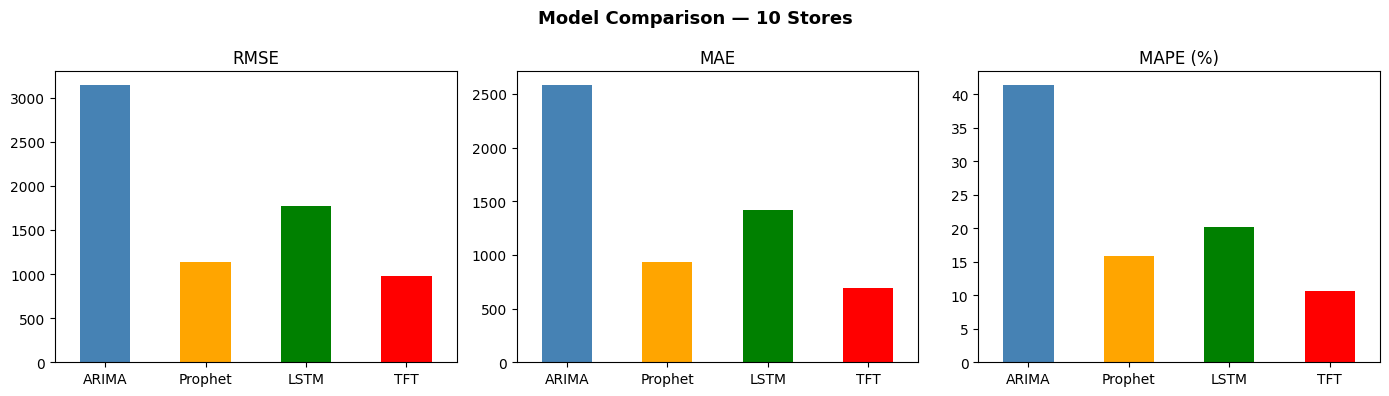

In [ ]:
results = pd.DataFrame([
    {
        "Model": "ARIMA",
        "RMSE": np.mean(arima_rmse),
        "MAE": np.mean(arima_mae),
        "MAPE (%)": np.nanmean(arima_mape),
        "Train Time (s)": arima_time,
        "Peak Memory (MB)": arima_mem,
    },
    {
        "Model": "Prophet",
        "RMSE": np.mean(prophet_rmse),
        "MAE": np.mean(prophet_mae),
        "MAPE (%)": np.nanmean(prophet_mape),
        "Train Time (s)": prophet_time,
        "Peak Memory (MB)": prophet_mem,
    },
    {
        "Model": "LSTM",
        "RMSE": np.mean(lstm_rmse),
        "MAE": np.mean(lstm_mae),
        "MAPE (%)": np.nanmean(lstm_mape),
        "Train Time (s)": lstm_time,
        "Peak Memory (MB)": lstm_mem,
    },
    {
        "Model": "TFT",
        "RMSE": np.mean(tft_rmse),
        "MAE": np.mean(tft_mae),
        "MAPE (%)": np.nanmean(tft_mape),
        "Train Time (s)": tft_time,
        "Peak Memory (MB)": tft_mem,
    },
])

results = results.set_index("Model").round(2)
print(results.to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ["RMSE", "MAE", "MAPE (%)"]):
    results[metric].plot(kind="bar", ax=ax, color=["steelblue","orange","green","red"])
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
plt.suptitle("Model Comparison — 10 Stores", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Final Model Comparison & Recommendations

Based on the evaluation of RMSE, MAE, MAPE, and computational costs, here is the summary of when to deploy each model:

* **ARIMA:** The classic statistical baseline. Best for simple, univariate data with clear linear trends and small datasets. **Recommendation:** Avoid for complex retail data; it cannot natively handle multiple seasonalities or sudden external shocks (like promotions), and its automated parameter search is surprisingly slow.
* **Prophet:** A robust, extremely fast curve-fitting model. Ideal for large-scale, automated forecasting with strong human-driven seasonalities (days of the week, holidays). **Recommendation:** Use as an advanced baseline. It trains in seconds and handles missing data well, but struggles to map complex, non-linear interactions between multiple external variables.
* **LSTM:** A deep learning model built for sequential memory. Excellent for complex, non-linear patterns (like IoT sensor or high-frequency data) where the immediate past strictly dictates the future. **Recommendation:** Less effective for this specific retail use case. It acts as an uninterpretable "black box", requires high compute, and struggles to proactively integrate known future calendar events.
* **TFT (Temporal Fusion Transformer):** Very powerful attention model. **Recommendation:** The absolute gold standard for retail forecasting. It easily yielded the lowest error rates by successfully separating and combining static metadata (Store ID), future knowns (Promotions), and past history. It provides built-in risk assessment (probabilistic quantiles) and high explainability (variable importance). The only trade-off is its massive computational cost (both memory and time), which practically requires a GPU for full-scale deployment.